<a href="https://colab.research.google.com/github/Ishany0/PM2.5_AirQuality/blob/main/Using_inbuilt_model_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [20]:

PSRA_data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')
df = pd.DataFrame(PSRA_data)

df = df.dropna()
encoded_df = pd.get_dummies(df , columns = ['cbwd'] , drop_first = True)



In [21]:
X = encoded_df[encoded_df.columns[7:14]]
Y = pd.Series(encoded_df['pm2.5'])
print(df.columns.tolist())          # confirm what's actually at position 7:14 now
print(X.isna().sum())

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)


['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
TEMP       0
PRES       0
Iws        0
Is         0
Ir         0
cbwd_NW    0
cbwd_SE    0
dtype: int64


In [22]:
model = LinearRegression()
model.fit(X_train , Y_train)

LinearRegression()

In [23]:
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [ -3.5132297   -3.10891895  -0.35595175  -0.32974441  -3.26238299
 -32.07831581  10.85172124]
Model Intercept: 3317.8699252941883


In [24]:
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
print(y_pred)

[133.55606766  95.02481844 112.15162467 ... 125.28190808 145.33334825
  88.50131637]


Train R²: 0.1496  |  Test R²: 0.1490
Train RMSE: 84.4615  |  Test RMSE: 86.5964


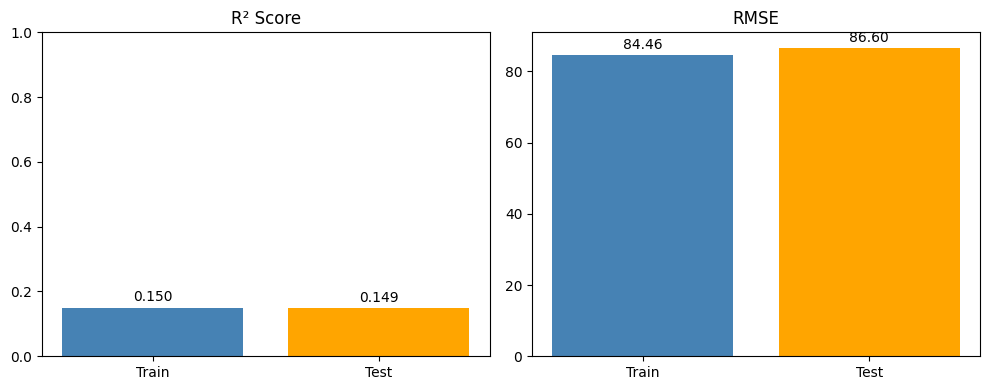

In [26]:
from sklearn.metrics import r2_score, root_mean_squared_error


train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_pred)
train_rmse = root_mean_squared_error(Y_train, y_train_pred)
test_rmse = root_mean_squared_error(Y_test, y_pred)
print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [train_r2, test_r2], color=['steelblue', 'orange'])
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate([train_r2, test_r2]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center')

axes[1].bar(['Train', 'Test'], [train_rmse, test_rmse], color=['steelblue', 'orange'])
axes[1].set_title('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v + max(train_rmse, test_rmse) * 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()
